#### Part A - Handling Missing Values

In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer, MissingIndicator, IterativeImputer

In [297]:
# Load dataset

data = pd.read_csv('patient_health_records.csv')
data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,69.0,Male,South,29.140042,119.967503,175.880159,87.704018,1
1,P0002,NaN,Male,West,32.240988,139.080885,233.505779,112.649952,0
2,P0003,89.0,Female,East,27.150680,102.695640,218.580412,102.578273,0
3,P0004,78.0,Male,North,23.074774,121.704367,244.911816,113.778262,0
4,P0005,38.0,Male,West,25.785560,114.053463,205.870489,115.380798,0


In [298]:
# INFO

print(f'Missing values percentage: \n{
data.isnull().sum() / len(data) *100}')

Missing values percentage: 
patient_id         0.0
age               10.0
gender            10.0
region            10.0
bmi                9.8
blood_pressure     0.0
cholesterol        9.6
glucose            9.8
disease_risk       0.0
dtype: float64


In [299]:
print(f'Describe: \n{data.describe()}')

Describe: 
              age         bmi  blood_pressure  cholesterol     glucose  \
count  900.000000  902.000000     1000.000000   904.000000  902.000000   
mean    52.708889   26.839617      122.977126   191.914894  108.413610   
std     20.954363    5.783429       21.986566    45.789680   45.244413   
min     18.000000   10.211299       69.907497    80.776090   53.023842   
25%     34.750000   23.799395      110.407875   166.674909   91.102469   
50%     52.000000   26.741862      120.713856   189.485116  100.740439   
75%     71.000000   29.480797      131.710686   211.606497  111.265799   
max     89.000000   64.421470      239.844896   497.142770  393.786076   

       disease_risk  
count   1000.000000  
mean       0.422000  
std        0.494126  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  


In [300]:
print(f'Info: \n{data.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   str    
 1   age             900 non-null    float64
 2   gender          900 non-null    str    
 3   region          900 non-null    str    
 4   bmi             902 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     904 non-null    float64
 7   glucose         902 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 70.4 KB
Info: 
None


In [301]:
# SimpleImputer

data_simp = data.copy()

mean_imp = SimpleImputer(strategy='mean')
median_imp = SimpleImputer(strategy='median')
freq_imp = SimpleImputer(strategy='most_frequent')

data_simp['bmi'] = mean_imp.fit_transform(data_simp[['bmi']])
data_simp[['age','cholesterol','glucose']] = median_imp.fit_transform(data_simp[['age','cholesterol','glucose']])
data_simp[['gender','region']] = freq_imp.fit_transform(data_simp[['gender','region']])

print(f'SimpleImputer: \n{data_simp}')

SimpleImputer: 
    patient_id   age  gender region        bmi  blood_pressure  cholesterol  \
0        P0001  69.0    Male  South  29.140042      119.967503   175.880159   
1        P0002  52.0    Male   West  32.240988      139.080885   233.505779   
2        P0003  89.0  Female   East  27.150680      102.695640   218.580412   
3        P0004  78.0    Male  North  23.074774      121.704367   244.911816   
4        P0005  38.0    Male   West  25.785560      114.053463   205.870489   
..         ...   ...     ...    ...        ...             ...          ...   
995      P0996  27.0  Female  North  30.797070      112.479519   194.004461   
996      P0997  52.0  Female  South  24.818420      105.567162   179.760156   
997      P0998  72.0  Female   East  31.950468      127.536709   189.653461   
998      P0999  49.0    Male  North  26.839617      117.615964   169.801326   
999      P1000  67.0    Male  North  30.077472      113.722935   189.485116   

        glucose  disease_risk  
0  

In [302]:
# Missing Indicator + Random Sample Imputation

data_rand = data.copy()

def random_sample_imp(df ,col, random_state=9009):
    np.random.seed(random_state)

    null_count = df[col].isnull().sum()

    if null_count > 0:
        random_value = df[col].dropna().sample(
            n=null_count,
            replace=True,
            random_state=random_state
        ).values

        df_ = df.copy()
        df_.loc[df_[col].isnull(), col] = random_value

        return df_

    return df


indicator = MissingIndicator(features='missing-only')
indicator_array = indicator.fit_transform(data)
indicator_col = [data.columns[col] + '_Missing' for col in indicator.features_]
indicator_df = pd.DataFrame(indicator_array.astype(int), columns=indicator_col)


imputed_df = data.copy()
for col in data.columns:
    imputed_df = random_sample_imp(imputed_df,col)


data_rand = pd.concat([imputed_df, indicator_df], axis=1)
print(f'Missing Indicator + Random Sample Imputation: \n{data_rand}')

Missing Indicator + Random Sample Imputation: 
    patient_id   age  gender region        bmi  blood_pressure  cholesterol  \
0        P0001  69.0    Male  South  29.140042      119.967503   175.880159   
1        P0002  74.0    Male   West  32.240988      139.080885   233.505779   
2        P0003  89.0  Female   East  27.150680      102.695640   218.580412   
3        P0004  78.0    Male  North  23.074774      121.704367   244.911816   
4        P0005  38.0    Male   West  25.785560      114.053463   205.870489   
..         ...   ...     ...    ...        ...             ...          ...   
995      P0996  27.0  Female  North  30.797070      112.479519   194.004461   
996      P0997  87.0  Female  South  24.818420      105.567162   179.760156   
997      P0998  72.0  Female   East  31.950468      127.536709   189.653461   
998      P0999  49.0    Male  North  21.101805      117.615964   169.801326   
999      P1000  67.0    Male  North  30.077472      113.722935   214.332650   

    

In [303]:
# KNNImputer

data_knn = data.copy()

data_knn_id = data_knn['patient_id'].copy()
data_knn.drop(['patient_id'], axis=1, inplace=True)

data_knn['gender']= data_knn['gender'].map({'Male':0, 'Female':1})
data_knn['region'] = data_knn['region'].map({'East':0, 'West':1, 'North':2, 'South':3})

knn = KNNImputer(n_neighbors=5, weights='distance')
data_knn = pd.DataFrame(knn.fit_transform(data_knn),columns=data_knn.columns)


data_knn['gender'] = data_knn['gender'].round().astype(int)
data_knn['region'] = data_knn['region'].round().astype(int)
data_knn['gender']= data_knn['gender'].map({0:'Male', 1:'Female'})
data_knn['region'] = data_knn['region'].map({0:'East', 1:'West', 2:'North', 3:'South'})

data_knn = pd.concat([data_knn, data_knn_id], axis=1)

print(f'KNN Imputer: \n{data_knn}')

KNN Imputer: 
           age  gender region        bmi  blood_pressure  cholesterol  \
0    69.000000    Male  South  29.140042      119.967503   175.880159   
1    57.410974    Male   West  32.240988      139.080885   233.505779   
2    89.000000  Female   East  27.150680      102.695640   218.580412   
3    78.000000    Male  North  23.074774      121.704367   244.911816   
4    38.000000    Male   West  25.785560      114.053463   205.870489   
..         ...     ...    ...        ...             ...          ...   
995  27.000000  Female  North  30.797070      112.479519   194.004461   
996  68.345275  Female  South  24.818420      105.567162   179.760156   
997  72.000000  Female   East  31.950468      127.536709   189.653461   
998  49.000000    Male  North  24.586742      117.615964   169.801326   
999  67.000000    Male  North  30.077472      113.722935   217.939911   

        glucose  disease_risk patient_id  
0     87.704018           1.0      P0001  
1    112.649952        

In [304]:
# MICE Algorithm

data_mice = data.copy()
data_mice_id = data_mice['patient_id'].copy()
data_mice.drop(['patient_id'], axis=1, inplace=True)

data_mice['gender']= data_mice['gender'].map({'Male':0, 'Female':1})
data_mice['region'] = data_mice['region'].map({'East':0, 'West':1, 'North':2, 'South':3})

imputer = IterativeImputer(max_iter=200, random_state=9009)
data_mice = pd.DataFrame(imputer.fit_transform(data_mice), columns=data_mice.columns)

data_mice['gender'] = data_mice['gender'].round().astype(int)
data_mice['region'] = data_mice['region'].round().astype(int)
data_mice['gender']= data_mice['gender'].map({0:'Male', 1:'Female'})
data_mice['region'] = data_mice['region'].map({0:'East', 1:'West', 2:'North', 3:'South'})

data_mice = pd.concat([data_mice, data_mice_id], axis=1)

print(f'MICE Algorithm: \n{data_mice}')


MICE Algorithm: 
           age  gender region        bmi  blood_pressure  cholesterol  \
0    69.000000    Male  South  29.140042      119.967503   175.880159   
1    53.110180    Male   West  32.240988      139.080885   233.505779   
2    89.000000  Female   East  27.150680      102.695640   218.580412   
3    78.000000    Male  North  23.074774      121.704367   244.911816   
4    38.000000    Male   West  25.785560      114.053463   205.870489   
..         ...     ...    ...        ...             ...          ...   
995  27.000000  Female  North  30.797070      112.479519   194.004461   
996  52.607475  Female  South  24.818420      105.567162   179.760156   
997  72.000000  Female   East  31.950468      127.536709   189.653461   
998  49.000000    Male  North  26.826382      117.615964   169.801326   
999  67.000000    Male  North  30.077472      113.722935   188.127459   

        glucose  disease_risk patient_id  
0     87.704018           1.0      P0001  
1    112.649952     

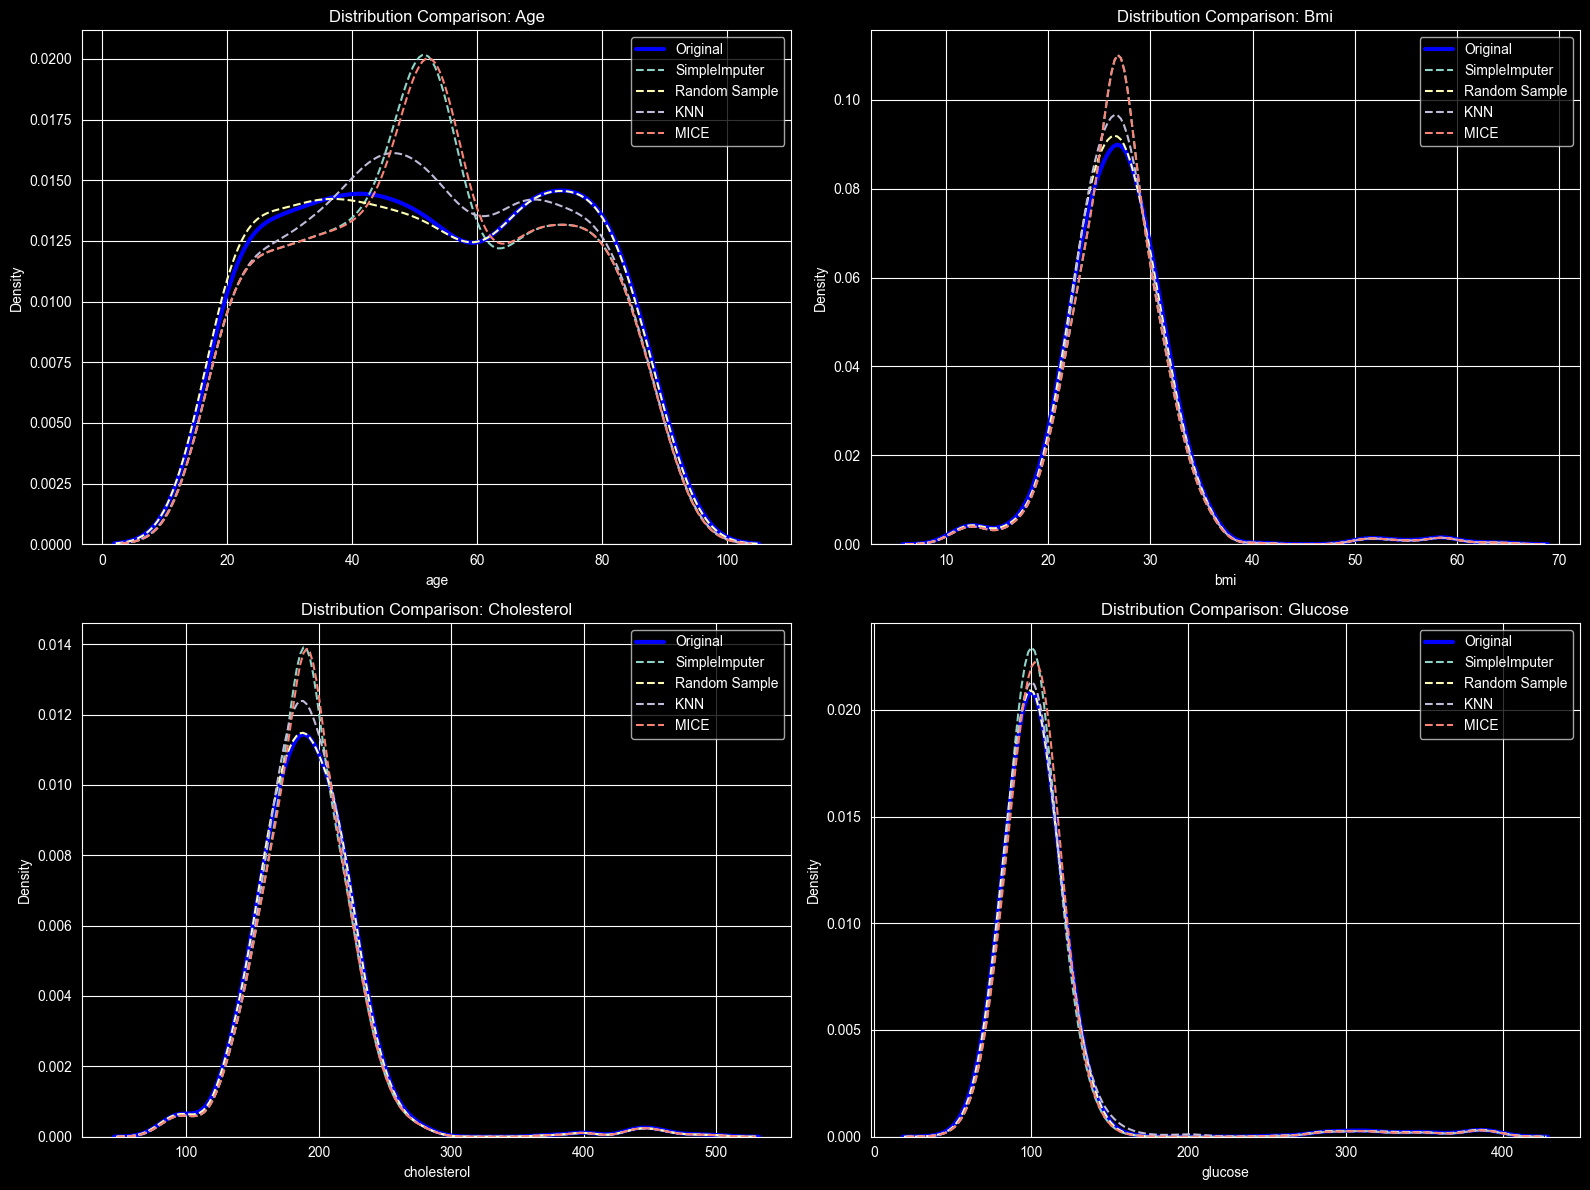

In [305]:
# Compare

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cols_to_compare = ['age', 'bmi', 'cholesterol', 'glucose']

for i, col in enumerate(cols_to_compare):
    sns.kdeplot(data[col].dropna(), label='Original', ax=axes[i], linewidth=3, color='blue')
    sns.kdeplot(data_simp[col], label='SimpleImputer', ax=axes[i], linestyle='--')
    sns.kdeplot(data_rand[col], label='Random Sample', ax=axes[i], linestyle='--')
    sns.kdeplot(data_knn[col], label='KNN', ax=axes[i], linestyle='--')
    sns.kdeplot(data_mice[col], label='MICE', ax=axes[i], linestyle='--')

    axes[i].set_title(f'Distribution Comparison: {col.capitalize()}')
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Part B - Handling Outliers

In [306]:
# Z-score method
# We will use dataset with MICE algorithm applied.

def z_score(df, cols, threshold):
    zdf = pd.DataFrame()
    df_clean = df.copy()

    for col in cols:
        mean = df_clean[col].mean()
        std = df_clean[col].std()

        z = (df_clean[col] - mean) / std
        zdf[col + '_Zscore'] = z

        df_clean = df_clean[z.abs() < threshold]

    return zdf, df_clean

data_z, data_z_clean = z_score(df=data_mice,cols=['age', 'bmi', 'cholesterol', 'glucose'],threshold=3)
print(f'Applied Z-Score: \n{data_z_clean}')

Applied Z-Score: 
           age  gender region        bmi  blood_pressure  cholesterol  \
0    69.000000    Male  South  29.140042      119.967503   175.880159   
1    53.110180    Male   West  32.240988      139.080885   233.505779   
2    89.000000  Female   East  27.150680      102.695640   218.580412   
3    78.000000    Male  North  23.074774      121.704367   244.911816   
4    38.000000    Male   West  25.785560      114.053463   205.870489   
..         ...     ...    ...        ...             ...          ...   
994  49.000000    Male   West  24.114419      116.061895   175.071749   
995  27.000000  Female  North  30.797070      112.479519   194.004461   
996  52.607475  Female  South  24.818420      105.567162   179.760156   
997  72.000000  Female   East  31.950468      127.536709   189.653461   
998  49.000000    Male  North  26.826382      117.615964   169.801326   

        glucose  disease_risk patient_id  
0     87.704018           1.0      P0001  
1    112.649952    

In [307]:
# IQR

def IQR(df,cols):
    df_clean = df.copy()

    for col in cols:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (df_clean[col] < lower) | (df_clean[col] > upper)

        df_clean = df_clean[~mask]

    return df_clean

data_iqr_clean = IQR(df=data_mice,cols=['age', 'bmi', 'cholesterol', 'glucose'])
print(f'Applied IQR: \n{data_iqr_clean}')

Applied IQR: 
           age  gender region        bmi  blood_pressure  cholesterol  \
0    69.000000    Male  South  29.140042      119.967503   175.880159   
1    53.110180    Male   West  32.240988      139.080885   233.505779   
2    89.000000  Female   East  27.150680      102.695640   218.580412   
3    78.000000    Male  North  23.074774      121.704367   244.911816   
4    38.000000    Male   West  25.785560      114.053463   205.870489   
..         ...     ...    ...        ...             ...          ...   
994  49.000000    Male   West  24.114419      116.061895   175.071749   
995  27.000000  Female  North  30.797070      112.479519   194.004461   
996  52.607475  Female  South  24.818420      105.567162   179.760156   
997  72.000000  Female   East  31.950468      127.536709   189.653461   
998  49.000000    Male  North  26.826382      117.615964   169.801326   

        glucose  disease_risk patient_id  
0     87.704018           1.0      P0001  
1    112.649952        

In [313]:
# Percentile Method

def percentile(df,cols,lower,upper):
    df_clean = df.copy()

    for col in cols:
        lower_bound = df_clean[col].quantile(lower)
        upper_bound = df_clean[col].quantile(upper)

        mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)

        df_clean = df_clean[~mask]

    return df_clean

data_percentile_clean = percentile(df=data_mice,cols=['age','bmi','cholesterol','glucose'],lower=0.05,upper=0.95)
print(f'Applied Percentile: \n{data_percentile_clean}')

Applied Percentile: 
           age  gender region        bmi  blood_pressure  cholesterol  \
0    69.000000    Male  South  29.140042      119.967503   175.880159   
1    53.110180    Male   West  32.240988      139.080885   233.505779   
4    38.000000    Male   West  25.785560      114.053463   205.870489   
5    41.000000    Male  South  30.570164      140.949427   191.708633   
7    39.000000    Male  South  21.679433      120.006319   159.390954   
..         ...     ...    ...        ...             ...          ...   
992  72.000000  Female   East  20.995831      136.584475   168.982665   
994  49.000000    Male   West  24.114419      116.061895   175.071749   
996  52.607475  Female  South  24.818420      105.567162   179.760156   
997  72.000000  Female   East  31.950468      127.536709   189.653461   
998  49.000000    Male  North  26.826382      117.615964   169.801326   

        glucose  disease_risk patient_id  
0     87.704018           1.0      P0001  
1    112.649952 

In [309]:
print('Shape')
print('\nBefore:')
print(f'Original: {data_mice.shape}')

print('\nAfter:')
print(f'Z-score Method: {data_z_clean.shape}')
print(f'IQR Method: {data_iqr_clean.shape}')
print(f'Percentile Method: {data_percentile_clean.shape}')

Shape

Before:
Original: (1000, 9)

After:
Z-score Method: (939, 9)
IQR Method: (879, 9)
Percentile Method: (659, 9)


#### Part C - Final Clean Dataset

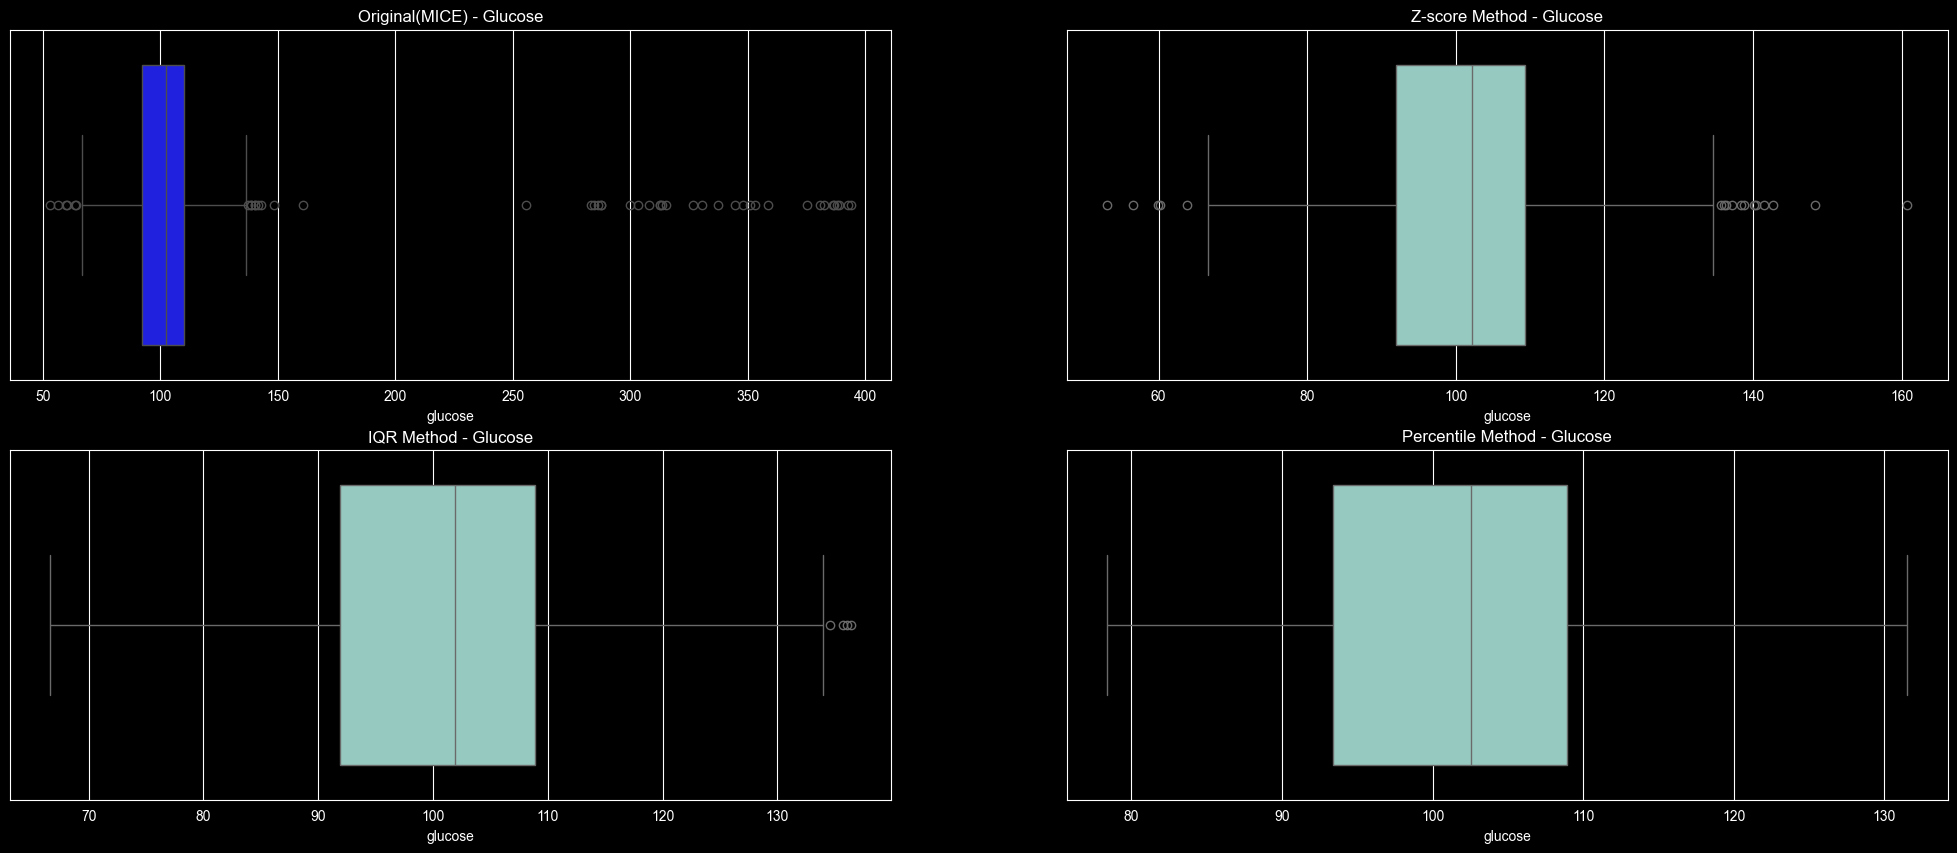

As you can see the best method for removing outliers was percentile but the data loss is high. Second best was IQR but I think this is best overall because the data loss is minimal compare to the percentile method.


In [310]:
# Compare

fig, axes = plt.subplots(2, 2, figsize=(25, 10))
axes = axes.flatten()

sns.boxplot(data_mice['glucose'], label='Original', ax=axes[0],color='blue', orient='h')
sns.boxplot(data_z_clean['glucose'], label='Z-score Method', ax=axes[1], orient='h')
sns.boxplot(data_iqr_clean['glucose'], label='IQR Method', ax=axes[2], orient='h')
sns.boxplot(data_percentile_clean['glucose'], label='Percentile Method', ax=axes[3], orient='h')

axes[0].set_title('Original(MICE) - Glucose')
axes[1].set_title('Z-score Method - Glucose')
axes[2].set_title('IQR Method - Glucose')
axes[3].set_title('Percentile Method - Glucose')

plt.show()

print('As you can see the best method for removing outliers was percentile but the data loss is high. Second best was IQR but I think this is best overall because the data loss is minimal compare to the percentile method.')


In [311]:
# Report

print("1. Most Effective Imputation Strategy:")
print("KNN and MICE were the most effective imputation strategies because they preserved the original variance and natural distribution of the data, unlike simple mean/median imputation.\n")

print("2. Best Outlier Handling Method:")
print("The IQR method preserved data quality best overall. While the Percentile method removed the most outliers, it resulted in high data loss. IQR provided the best balance by handling extreme values with minimal data loss.\n")

print("3. Dataset Usability Improvement:")
print("Data cleaning improved dataset usability by ensuring complete records and reducing the impact of extreme skewness. This makes the data reliable and ready for training the downstream heart disease prediction model.")

1. Most Effective Imputation Strategy:
KNN and MICE were the most effective imputation strategies because they preserved the original variance and natural distribution of the data, unlike simple mean/median imputation.

2. Best Outlier Handling Method:
The IQR method preserved data quality best overall. While the Percentile method removed the most outliers, it resulted in high data loss. IQR provided the best balance by handling extreme values with minimal data loss.

3. Dataset Usability Improvement:
Data cleaning improved dataset usability by ensuring complete records and reducing the impact of extreme skewness. This makes the data reliable and ready for training the downstream heart disease prediction model.


In [312]:
# Save csv

print('Final Cleaned Dataset Overview:')
print(f"Final Dataset Shape: {data_iqr_clean.shape}")

print('\nConfirming No Missing Values:')
print(data_iqr_clean.isnull().sum())

print('\nFinal Dataset Preview:')
display(data_iqr_clean.head())

data_iqr_clean.to_csv("final_clean_patient_health_records.csv", index=False)

Final Cleaned Dataset Overview:
Final Dataset Shape: (879, 9)

Confirming No Missing Values:
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
patient_id        0
dtype: int64

Final Dataset Preview:


,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,patient_id
0,69.00000,Male,South,29.140042,119.967503,175.880159,87.704018,1.0,P0001
1,53.11018,Male,West,32.240988,139.080885,233.505779,112.649952,0.0,P0002
2,89.00000,Female,East,27.150680,102.695640,218.580412,102.578273,0.0,P0003
3,78.00000,Male,North,23.074774,121.704367,244.911816,113.778262,0.0,P0004
4,38.00000,Male,West,25.785560,114.053463,205.870489,115.380798,0.0,P0005
